---

ใช้ชุดข้อมูล "number_hand_writting.csv"
  
ซึ่งเป็นข้อมูลที่แปลงมาจากภาพลายมือการเขียนเลข 0 - 9 โดยมีรายละเอียดของแต่ละคอลัมน์ดังนี้    
F1-F64: ความเข้มของลายมือในแต่ละช่อง โดย 1 ภาพลายมือจะเป็นตาราง 8x8 = 64 ช่อง ในแต่ละช่องความเข้มจะมีค่า 0-16  
Class:  label ว่าข้อมูลแถวนั้นเป็นเลขอะไร  

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

df_handw = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/number_hand_writting.csv")
df_handw.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F56,F57,F58,F59,F60,F61,F62,F63,F64,Class
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6


In [27]:
df_handw.iloc[0,0:64].values.reshape(8,8)

array([[ 0,  1,  6, 15, 12,  1,  0,  0],
       [ 0,  7, 16,  6,  6, 10,  0,  0],
       [ 0,  8, 16,  2,  0, 11,  2,  0],
       [ 0,  5, 16,  3,  0,  5,  7,  0],
       [ 0,  7, 13,  3,  0,  8,  7,  0],
       [ 0,  4, 12,  0,  1, 13,  5,  0],
       [ 0,  0, 14,  9, 15,  9,  0,  0],
       [ 0,  0,  6, 14,  7,  1,  0,  0]], dtype=int64)

ให้เลือกใช้ SVM หรือ ANN ในการสร้างโมเดลเพื่อทำนายว่าเป็นตัวเลขใดจากข้อมูลลายมือ โดยมีรายละเอียดดังนี้  
- ให้ 'Class' เป็นข้อมูล outcome (y) และ 'F1' - 'F64' เป็นข้อมูล feature (X)  
- มีการแบ่งข้อมูลเป็น training set และ test set โดยใช้ train_test_split ซึ่งมี argument test_size=0.3 และ random_state=1234
- สร้างโมเดลจากข้อมูล training set ต้องทำ k-fold cross-validation เพื่อทำการ optimize parameter โดยให้เลือก parameter ที่จะทำการ optimize ตามความเหมาะสม (อย่างน้อย 1 parameter)
    - สำหรับ SVM สามารถทำการ optimize: kernel, C, gamma, etc.
    - สำหรับ ANN สามารถทำการ optimize: hidden_layer_sizes, activation, solver, learning_rate_initfloat, learning_rate, etc.
    - การทำ k-fold cross-validation ให้ใช้ StratifiedKFold โดย n_splits=5, shuffle=True, และ random_state=1234
- สร้างโมเดลสุดท้ายจาก prameter ที่ optimize ได้ แล้วนำไปทดสอบประสิทธิภาพในการทำนาย 'Class' ของ test set โดยประสิทธิภาพการทำนายที่วัดคือ accuracy
- แสดง confusion matrix ที่ได้จากการทำนาย 'Class' ของ test set พร้อมทั้งแสดง accuracy ที่ได้

In [32]:
# Separate Data
X = df_handw.drop(columns=['Class'])
X

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F55,F56,F57,F58,F59,F60,F61,F62,F63,F64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,0,0,4,10,13,6,0,0,0,1,...,4,0,0,0,2,14,15,9,0,0
5616,0,0,6,16,13,11,1,0,0,0,...,1,0,0,0,6,16,14,6,0,0
5617,0,0,1,11,15,1,0,0,0,0,...,0,0,0,0,2,9,13,6,0,0
5618,0,0,2,10,7,0,0,0,0,0,...,2,0,0,0,5,12,16,12,0,0


In [33]:
# Separate Label
y = df_handw['Class']
y

0       0
1       0
2       7
3       4
4       6
       ..
5615    9
5616    0
5617    8
5618    9
5619    8
Name: Class, Length: 5620, dtype: int64

In [36]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1234)

In [42]:
X_train.shape

(3934, 64)

In [43]:
X_test.shape

(1686, 64)

In [45]:
y_train.shape

(3934,)

In [44]:
y_test.shape

(1686,)

In [55]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train) #Scaling parameters must based on training data.

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [56]:
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_train_sc.std(numeric_only=True)

F1     0.000000
F2     0.110172
F3     0.292642
F4     0.270062
F5     0.278180
         ...   
F60    0.274533
F61    0.309362
F62    0.361210
F63    0.249884
F64    0.087182
Length: 64, dtype: float64

In [57]:
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)
X_test_sc.std(numeric_only=True)

F1     0.000000
F2     0.109613
F3     0.290661
F4     0.255851
F5     0.280615
         ...   
F60    0.264981
F61    0.314756
F62    0.368712
F63    0.259982
F64    0.092030
Length: 64, dtype: float64

In [61]:
# Setup SVM Model
from sklearn import svm
svm_l = svm.SVC(kernel='linear',
                C=1,
                probability=True)

In [62]:
# Setup cross-validation
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

In [67]:
# Evaluate Training Performance
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=svm_l, # svm with linear kernel
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)

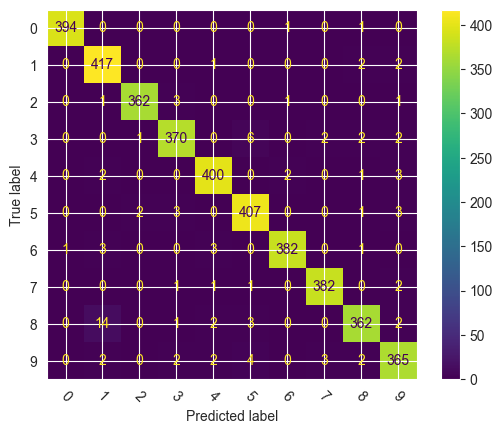

In [72]:
# Evaluate Performance Metrics
conf_mat = metrics.confusion_matrix(y_train, y_pred)
metrics.ConfusionMatrixDisplay(conf_mat).plot(xticks_rotation=-45)

In [70]:
print(metrics.classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       396
           1       0.95      0.99      0.97       422
           2       0.99      0.98      0.99       368
           3       0.97      0.97      0.97       383
           4       0.98      0.98      0.98       408
           5       0.97      0.98      0.97       416
           6       0.99      0.98      0.98       390
           7       0.99      0.99      0.99       387
           8       0.97      0.94      0.96       384
           9       0.96      0.96      0.96       380

    accuracy                           0.98      3934
   macro avg       0.98      0.98      0.98      3934
weighted avg       0.98      0.98      0.98      3934



In [71]:
acc = metrics.accuracy_score(y_train, y_pred)
precision = metrics.precision_score(y_train, y_pred, average='weighted')
recall = metrics.recall_score(y_train, y_pred, average='weighted')
f1 = metrics.f1_score(y_train, y_pred, average='weighted')

print(f"acc={acc:.2f}")
print(f"precision={precision:.2f}")
print(f"recall={recall:.2f}")
print(f"f1={f1:.2f}")

acc=0.98
precision=0.98
recall=0.98
f1=0.98


In [77]:
y_pred_proba = cross_val_predict(estimator=svm_l,
                                 method='predict_proba',
                                 X=X_train_sc,
                                 y=y_train,
                                 cv=skf)

In [81]:
auc_ovo = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovo', average='weighted')
print(auc_ovo)

auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')
print(auc_ovr)

0.9994791849661685
0.9994782194330339


In [93]:
# Tuning using K-Fold
cs = [c for c in range(1,101) if c%10==0 or c==1]
cs

[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

In [94]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

perf = {}
perf['C'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc_ovr'] = []
perf['matthew'] = []

for c in cs:
    model_svm = svm.SVC(kernel='linear',
                        C=c,
                        probability=True,
                        random_state=1234) # Controls the pseudo random number generation for shuffling the data for probability estimates.

    # predict class
    y_pred = cross_val_predict(estimator=model_svm,
                               X=X_train_sc,
                               y=y_train,
                               cv=skf)
    acc = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred, average='weighted')
    recall = metrics.recall_score(y_train, y_pred, average='weighted')
    f1 = metrics.f1_score(y_train, y_pred, average='weighted')
    matw = metrics.matthews_corrcoef(y_train, y_pred)

    # predict probabilities
    y_pred_proba = cross_val_predict(estimator=model_svm,
                                     method='predict_proba', # The default is 'predict' which not calculate probability
                                     X=X_train_sc,
                                     y=y_train,
                                     cv=skf)
    y_pred_proba = pd.DataFrame(y_pred_proba)
    auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')

    perf['C'].append(c)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc_ovr'].append(auc_ovr)
    perf['matthew'].append(matw)

perf = pd.DataFrame(perf)
perf.sort_values(by=['f1', 'matthew', 'auc_ovr'], ascending=[False, False, False]).head()

,C,acc,precision,recall,f1,auc_ovr,matthew
0,1,0.976360,0.976505,0.976360,0.976359,0.999492,0.973744
3,30,0.975343,0.975347,0.975343,0.975333,0.999285,0.972600
7,70,0.975089,0.975094,0.975089,0.975080,0.999197,0.972318
8,80,0.975089,0.975094,0.975089,0.975080,0.999197,0.972318
2,20,0.975089,0.975106,0.975089,0.975075,0.999327,0.972320


Text(0.5, 1.0, '5-fold cv performance scores at different C')

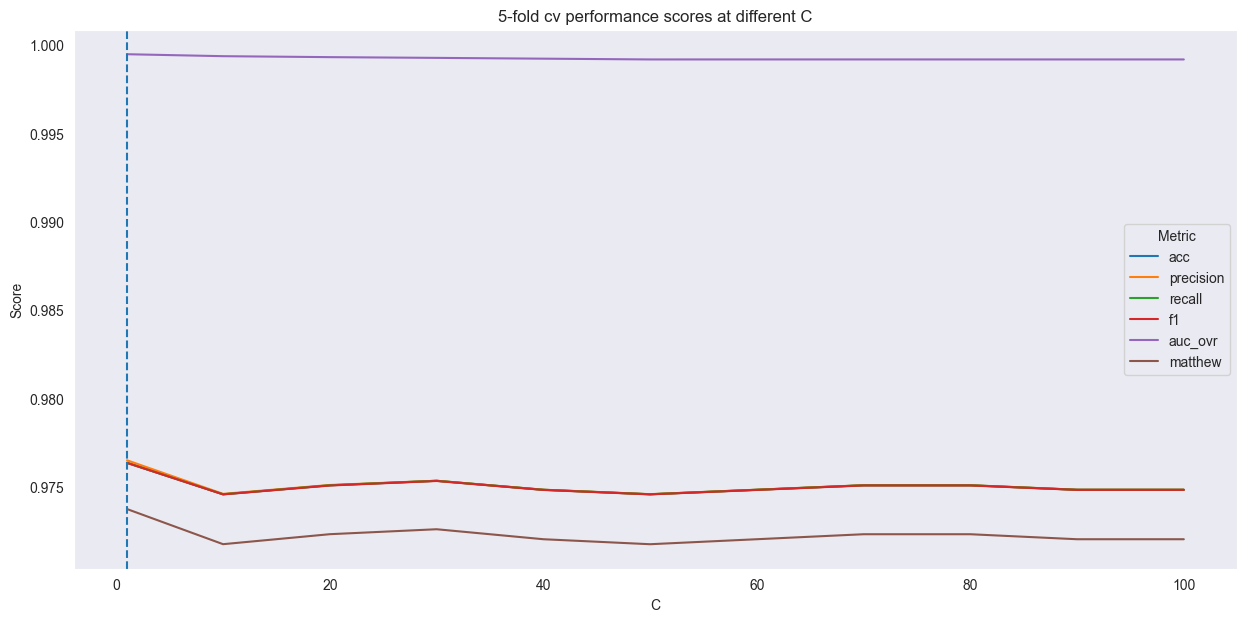

In [95]:
df_forPlot = pd.melt(perf,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc_ovr', 'matthew'],
                     id_vars = ['C'],
                     var_name = 'Metric',
                     value_name = 'Score')

fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(data = df_forPlot,
             x = 'C',
             y = 'Score',
             hue = 'Metric',
             ax=ax)
plt.grid()
plt.axvline(x=1, ls="--")
plt.title('5-fold cv performance scores at different C')

In [96]:
# Create SVM Model
svm_l = svm.SVC(kernel='linear',
                C=1,
                probability=True)
svm_l.fit(X=X_train_sc, y=y_train)

SVC(C=1, kernel='linear', probability=True)

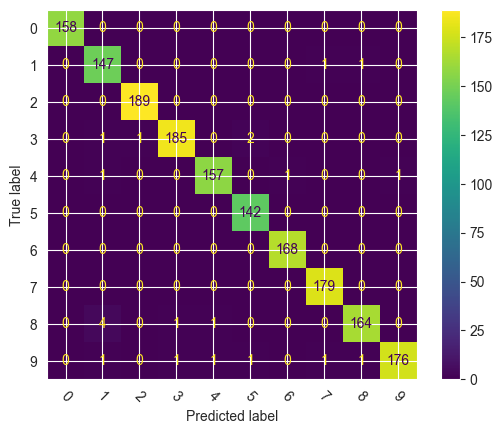

In [98]:
y_pred_test = svm_l.predict(X_test_sc)
y_pred_proba = svm_l.predict_proba(X_test_sc)

conf_mat = metrics.confusion_matrix(y_test, y_pred_test)
metrics.ConfusionMatrixDisplay(conf_mat).plot(xticks_rotation=-45)

In [101]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test, average='weighted')
recall = metrics.recall_score(y_test, y_pred_test, average='weighted')
f1 = metrics.f1_score(y_test, y_pred_test, average='weighted')
matw = metrics.matthews_corrcoef(y_test, y_pred_test)
auc_ovr = metrics.roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc_ovr: {auc_ovr:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.99
precision: 0.99
recall: 0.99
f1: 0.99
auc_ovr: 1.00
Matthew's corr coef: 0.99



---